# Caffeine Effects
Caffeine increase RyR opening sensitivity to luminal and subspace calcium
In this model, we decrease the mid saturation sub-SR calcium concentration for the opening rate

In [1]:
using ModelingToolkit
using OrdinaryDiffEq, SteadyStateDiffEq, DiffEqCallbacks
using Plots
using CSV
using DataFrames
using Dates
using CaMKIIModel
using CaMKIIModel: second
Plots.default(lw=1.5)

In [2]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)
tend = 500.0second
prob = ODEProblem(sys, [], tend)
stimstart = 100.0second
stimend = 300.0second
alg = KenCarp47()
function add_coffee_affect!(integrator)
    integrator.ps[sys.RyRsensitivity] = 10
end

@unpack Istim = sys
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)

SciMLBase.CallbackSet{Tuple{}, Tuple{SciMLBase.DiscreteCallback{DiffEqCallbacks.var"#111#113"{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}, CaMKIIModel.var"#13#15"{Float64, Int64, Symbolics.Num}, DiffEqCallbacks.var"#112#114"{typeof(SciMLBase.INITIALIZE_DEFAULT), Bool, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, CaMKIIModel.var"#13#15"{Float64, Int64, Symbolics.Num}}, typeof(SciMLBase.FINALIZE_DEFAULT), Nothing}, SciMLBase.DiscreteCallback{DiffEqCallbacks.var"#111#113"{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}, CaMKIIModel.var"#14#16"{Float64, Int64, Symbolics.Num}, DiffEqCallbacks.var"#112#114"{typeof(SciMLBase.INITIALIZE_DEFAULT), Bool, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, CaMKIIModel.var"#14#16"{Float64, Int64, Symbolics.Num}}, typeof(SciMLBase.FINALIZE_DEFAULT), Nothing}}}((), (SciMLBase.Discr

Add caffeine at t = 200 econd

In [3]:
callback_caf = CallbackSet(build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart), PresetTimeCallback(200.0second, add_coffee_affect!))

SciMLBase.CallbackSet{Tuple{}, Tuple{SciMLBase.DiscreteCallback{DiffEqCallbacks.var"#111#113"{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}, CaMKIIModel.var"#13#15"{Float64, Int64, Symbolics.Num}, DiffEqCallbacks.var"#112#114"{typeof(SciMLBase.INITIALIZE_DEFAULT), Bool, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, CaMKIIModel.var"#13#15"{Float64, Int64, Symbolics.Num}}, typeof(SciMLBase.FINALIZE_DEFAULT), Nothing}, SciMLBase.DiscreteCallback{DiffEqCallbacks.var"#111#113"{StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}}, CaMKIIModel.var"#14#16"{Float64, Int64, Symbolics.Num}, DiffEqCallbacks.var"#112#114"{typeof(SciMLBase.INITIALIZE_DEFAULT), Bool, StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}, CaMKIIModel.var"#14#16"{Float64, Int64, Symbolics.Num}}, typeof(SciMLBase.FINALIZE_DEFAULT), Nothing}, SciMLBase.DiscreteCal

In [4]:
@time sol = solve(prob, alg; callback)
@time sol_caf = solve(prob, alg; callback=callback_caf)

 11.298458 seconds (23.43 M allocations: 1.090 GiB, 3.59% gc time, 76.40% compilation time)
  5.066561 seconds (4.22 M allocations: 233.924 MiB, 1.20% gc time, 45.49% compilation time)


retcode: Success
Interpolation: 3rd order Hermite
t: 8895-element Vector{Float64}:
      0.0
      0.019333123284849308
      0.09098129546757994
      0.20735582943983855
      0.45611910276862533
      1.0472562928406122
      2.0342667657223696
      3.451776641148454
      6.733792423912806
     12.450117081023194
      ⋮
 404642.83277566
 414876.95827256143
 425667.56049853395
 437210.42549690785
 449697.91880315664
 462185.41210940544
 477837.27149518696
 495715.4111476532
 500000.0
u: 8895-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.0025985659590295374, 829.9994975880693, 829.9999654017583, 0.007020208561323646, 0.9660018276402699, 0.2215639938807744, 0.09242766669618695, 0.001879826176081169, 0.009769882842069916, 0.2608055799112056  …  0.12113000000000405, 0.12113000000038378, 0.1211300000138

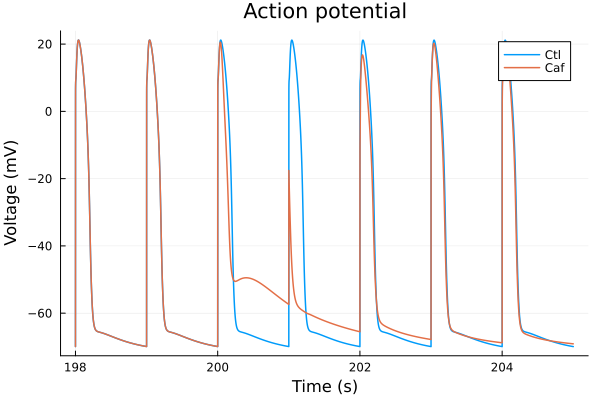

In [5]:
i = (sys.t / 1000, sys.vm)
plot(sol, idxs=i, title="Action potential", lab="Ctl", tspan=(198second, 205second))
plot!(sol_caf, idxs=i, lab="Caf", tspan=(198second, 205second), ylabel="Voltage (mV)", xlabel="Time (s)")

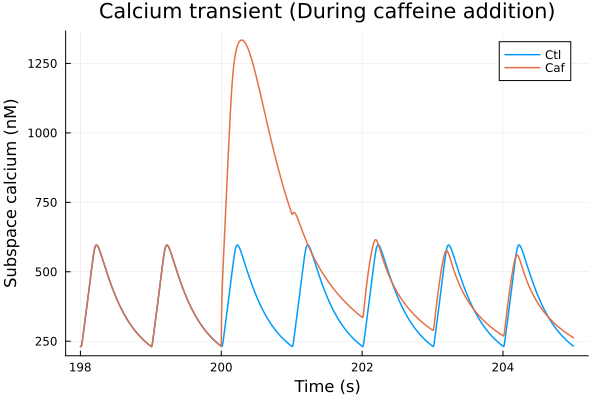

In [6]:
i = (sys.t / 1000, sys.Cai_sub_SR * 1000)
plot(sol, idxs=i, title="Calcium transient (During caffeine addition)", lab="Ctl", tspan=(198second, 205second))
plot!(sol_caf, idxs=i, tspan=(198second, 205second), lab="Caf", ylabel="Subspace calcium (nM)", xlabel="Time (s)")

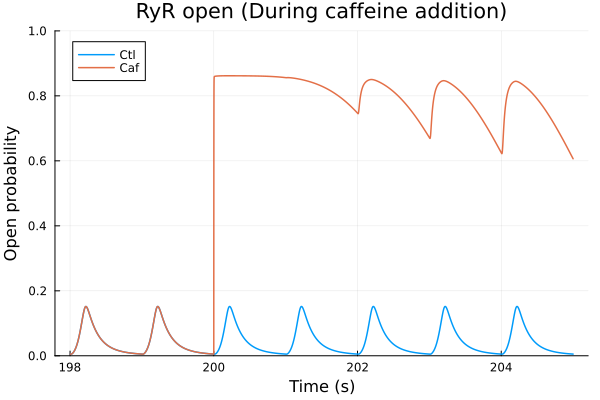

In [7]:
i = (sys.t / 1000, sys.PO1RyR)
plot(sol, idxs=i, title="RyR open (During caffeine addition)", lab="Ctl", tspan=(198second, 205second))
plot!(sol_caf, idxs=i, tspan=(198second, 205second), lab="Caf", ylabel="Open probability", ylims=(0, 1), xlabel="Time (s)")

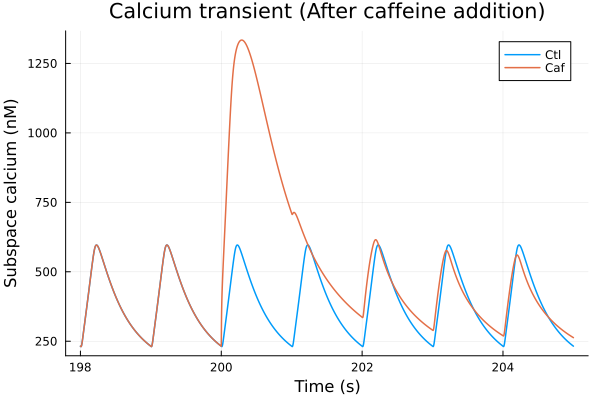

In [8]:
i = (sys.t / 1000, sys.Cai_sub_SR * 1000)
plot(sol, idxs=i, title="Calcium transient (After caffeine addition)", lab="Ctl", ylabel="Subspace calcium (nM)", tspan=(198second, 205second))
plot!(sol_caf, idxs=i, lab="Caf", xlabel="Time (s)", tspan=(198second, 205second))

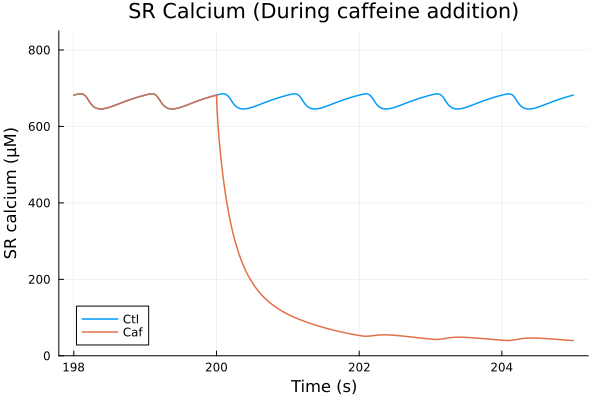

In [9]:
i = (sys.t / 1000, sys.CaJSR)
plot(sol, idxs=i, title="SR Calcium (During caffeine addition)", lab="Ctl", ylabel="SR calcium (μM)", tspan=(198second, 205second))
plot!(sol_caf, idxs=i, tspan=(198second, 205second), lab="Caf", ylims=(0, 850), xlabel="Time (s)")

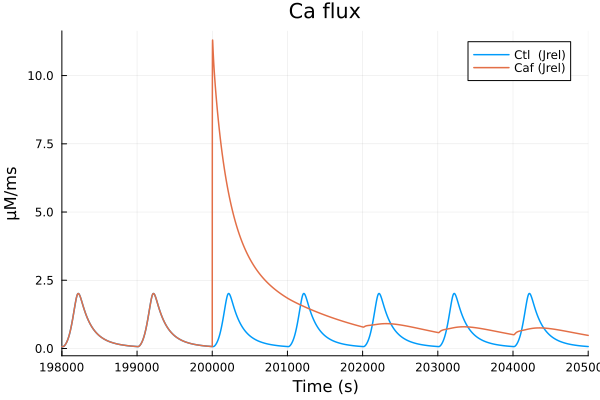

In [10]:
i = (sys.t / 1000, sys.Jrel)
plot(sol, idxs=sys.Jrel, title="Ca flux", lab="Ctl  (Jrel)", tspan=(198second, 205second))
plot!(sol_caf, idxs=sys.Jrel, lab="Caf (Jrel)", tspan=(198second, 205second), ylabel="μM/ms", xlabel="Time (s)")

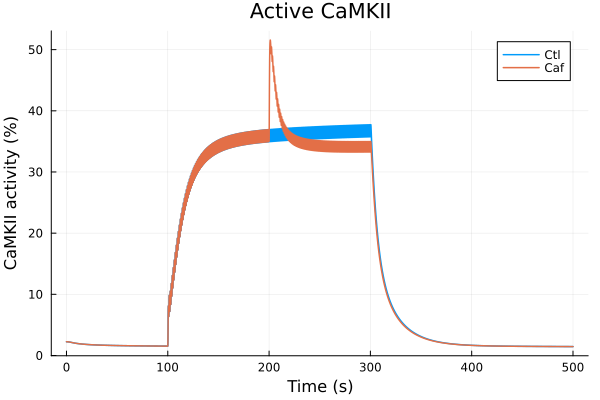

In [11]:
i = (sys.t / 1000, sys.CaMKAct * 100)
plot(sol, idxs=i, title="Active CaMKII", lab="Ctl")
plot!(sol_caf, idxs=i, lab="Caf", ylabel="CaMKII activity (%)", xlabel="Time (s)")

## Simulation vs experimental data
Add caffeine in the beginning of the simulation
Add caffeine and nifedipine in the beginning of the simulation (nifedipine blocks 90% of L-type calcium channel)

In [12]:
sys = build_neonatal_ecc_sys(simplify=true, reduce_iso=true, reduce_camk=true)
tend = 205second
stimstart = 30second
stimend = 120second
alg = KenCarp47()
@unpack Istim = sys
callback = build_stim_callbacks(Istim, stimend; period=1second, starttime=stimstart)

prob = ODEProblem(sys, [], tend)
prob_caf = ODEProblem(sys, [sys.RyRsensitivity => 10], tend)
gCaL = prob.ps[sys.GCaL]
prob_nif_caf = ODEProblem(sys, [sys.RyRsensitivity => 10, sys.GCaL => 0.1 * gCaL], tend)
@time sol = solve(prob, alg; callback)
@time sol_caf = solve(prob_caf, alg; callback)
@time sol_nif_caf = solve(prob_nif_caf, alg; callback)

  6.947371 seconds (20.53 M allocations: 909.659 MiB, 3.47% gc time, 83.67% compilation time)
  1.209385 seconds (39.06 k allocations: 8.509 MiB)
  0.811787 seconds (31.72 k allocations: 6.716 MiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 3176-element Vector{Float64}:
      0.0
      0.01909847405970621
      0.09056276966611176
      0.2066569852289616
      0.4547307783275887
      1.1953594354007893
      2.502500491431298
      4.2762382565127135
      7.010765847612886
     11.186106370617878
      ⋮
 141892.40379801008
 146683.15008929532
 152766.93500274056
 159602.04940327266
 167970.44149328943
 178627.4799712433
 190146.85513215893
 202276.8501284552
 205000.0
u: 3176-element Vector{Vector{Float64}}:
 [0.0026, 830.0, 830.0, 0.00702, 0.966, 0.22156, 0.09243, 0.00188, 0.00977, 0.26081  …  0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, 0.12113, -68.79268, 13838.37602, 150952.75035000002]
 [0.01720883026979937, 829.9981045688384, 829.9999655875564, 0.007020204633340147, 0.9660018054574051, 0.22156394540578322, 0.09242769501499327, 0.0018798275101706249, 0.00976988428390901, 0.26080563392118083  …  0.12113000000000329, 0.12113000000032005, 0.12113000001175

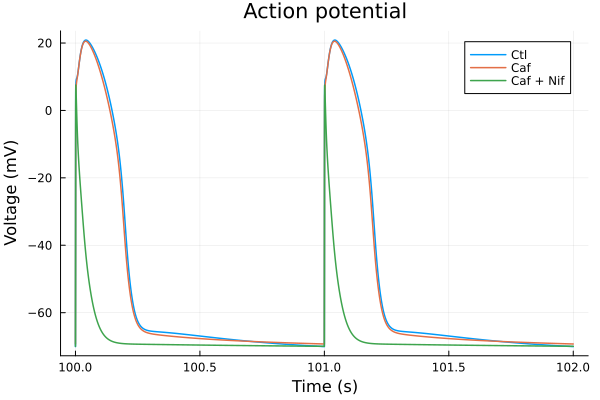

In [13]:
i = (sys.t / 1000, sys.vm)
tspan = (100second, 102second)
plot(sol, idxs=i, title="Action potential", lab="Ctl"; tspan)
plot!(sol_caf, idxs=i, lab="Caf"; tspan)
plot!(sol_nif_caf, idxs=i, lab="Caf + Nif", tspan=tspan, ylabel="Voltage (mV)", xlabel="Time (s)")

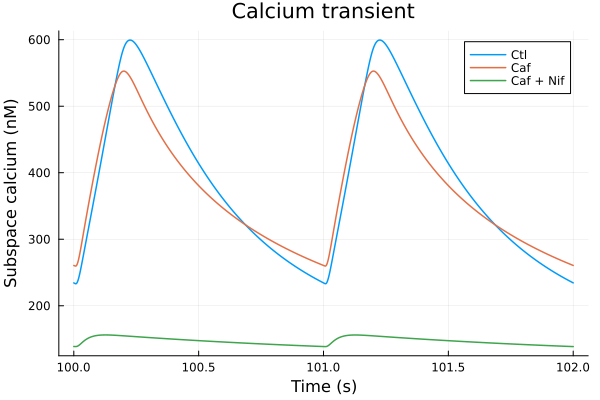

In [14]:
i = (sys.t / 1000, sys.Cai_sub_SR * 1000)
tspan = (100second, 102second)
plot(sol, idxs=i, title="Calcium transient", lab="Ctl"; tspan)
plot!(sol_caf, idxs=i, lab="Caf", ylabel="Subspace calcium (nM)"; tspan)
plot!(sol_nif_caf, idxs=i, lab="Caf + Nif", ylabel="Subspace calcium (nM)", xlabel="Time (s)"; tspan)

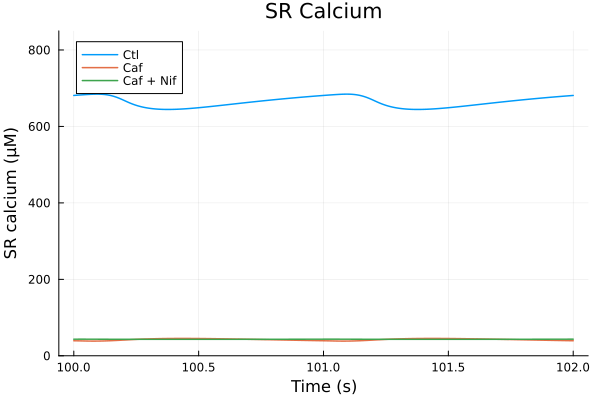

In [15]:
i = (sys.t / 1000, sys.CaJSR)
tspan = (100second, 102second)
plot(sol, idxs=i, title="SR Calcium", lab="Ctl", ylabel="SR calcium (μM)"; tspan)
plot!(sol_caf, idxs=i, lab="Caf"; tspan)
plot!(sol_nif_caf, idxs=i, lab="Caf + Nif", ylims=(0, 850), xlabel="Time (s)"; tspan)

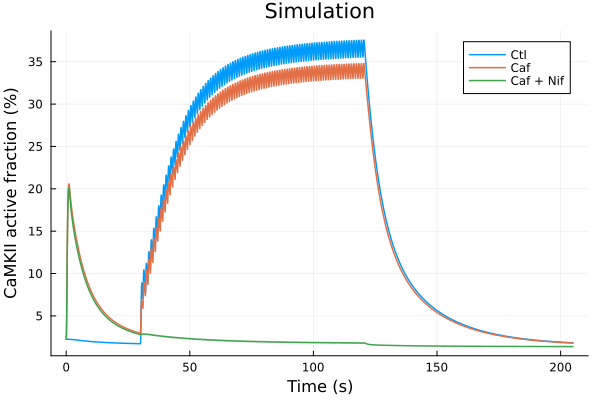

In [16]:
i = (sys.t / 1000, sys.CaMKAct * 100)
plot(sol, idxs=i, title="Simulation", lab="Ctl")
plot!(sol_caf, idxs=i, lab="Caf")
plot!(sol_nif_caf, idxs=i, lab="Caf + Nif", ylabel="CaMKII active fraction (%)", xlabel="Time (s)")

In [17]:
savefig("caf-camkact.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/caf-camkact.pdf"

experiments

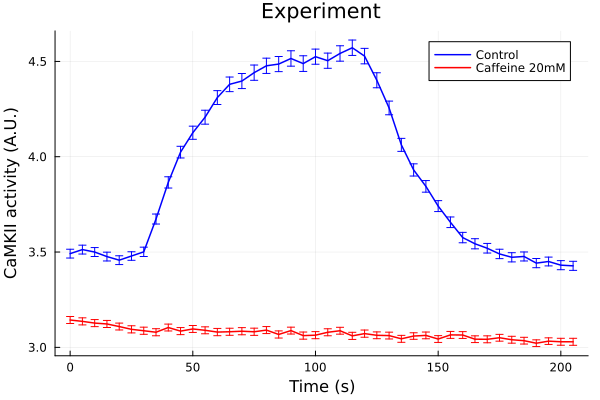

In [18]:
chemicaldf = CSV.read(joinpath(@__DIR__, "data/CaMKAR-chemical.csv"), DataFrame)
ts = Dates.value.(chemicaldf[!, "Time"]) ./ 10^9
ctl = chemicaldf[!, "Ctrl Mean"]
ctl_error = chemicaldf[!, "Ctrl SD"] ./ sqrt.(chemicaldf[!, "Ctrl N"])

caf = chemicaldf[!, "caffeine 20mM Mean"]
caf_error = chemicaldf[!, "caffeine 20mM SD"] ./ sqrt.(chemicaldf[!, "caffeine 20mM N"])

plot(ts, ctl, yerr=ctl_error, lab="Control", color=:blue, markerstrokecolor=:blue)
plot!(ts, caf, yerr=caf_error, lab="Caffeine 20mM", color=:red, markerstrokecolor=:red)
plot!(xlabel="Time (s)", ylabel="CaMKII activity (A.U.)", title= "Experiment")

In [19]:
savefig("caf-exp.pdf")

"/home/github/actions-runner-1/_work/camkii-cardiomyocyte-model/camkii-cardiomyocyte-model/.cache/docs/caf-exp.pdf"

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*